In [ ]:
# 1. Load and Explore Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/content/drive/MyDrive/Concept and Technology of AI/Disease Prediction Dataset.csv")

print("Dataset shape:", data.shape)
print("Columns:", data.columns)
print(data.info())
print(data.isnull().sum())
print(data.head())

Dataset shape: (5000, 6)
Columns: Index(['Fever', 'Headache', 'Cough', 'Fatigue', 'Body_Pain', 'Disease'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Fever      5000 non-null   float64
 1   Headache   5000 non-null   float64
 2   Cough      5000 non-null   float64
 3   Fatigue    5000 non-null   float64
 4   Body_Pain  5000 non-null   float64
 5   Disease    5000 non-null   object 
dtypes: float64(5), object(1)
memory usage: 234.5+ KB
None
Fever        0
Headache     0
Cough        0
Fatigue      0
Body_Pain    0
Disease      0
dtype: int64
        Fever  Headache     Cough   Fatigue  Body_Pain      Disease
0   98.283156  4.118632  2.687983  4.116661   8.470956    Body Ache
1   98.284660  6.963971  1.960734  5.495257   8.033919    Body Ache
2  103.622552  8.702915  2.854463  6.546993   2.205383      Malaria
3   98.254732  1.

In [ ]:
# 2. Handle Missing Values
from sklearn.impute import SimpleImputer

# Separate numeric and categorical columns
numeric_cols = data.select_dtypes(include=['float64','int64']).columns
categorical_cols = data.select_dtypes(include=['object']).columns

# Fill numeric NaNs with median
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Fill categorical NaNs with mode
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [ ]:
# 3. Encode Categorical Features
for col in categorical_cols:
    data[col] = data[col].astype('category').cat.codes

In [ ]:
# 4. Define Features and Target
target_col = 'Disease'
X = data.drop(target_col, axis=1)
y = data[target_col].astype('category').cat.codes

In [ ]:
# 5. Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# 6. Impute + Scale Features
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

# Convert back to DataFrame
feature_names = X.columns[:X_train_imp.shape[1]]
X_train = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test = pd.DataFrame(X_test_scaled, columns=feature_names)

Top 5 Selected Features: Index(['Fever', 'Headache', 'Cough', 'Fatigue', 'Body_Pain'], dtype='object')


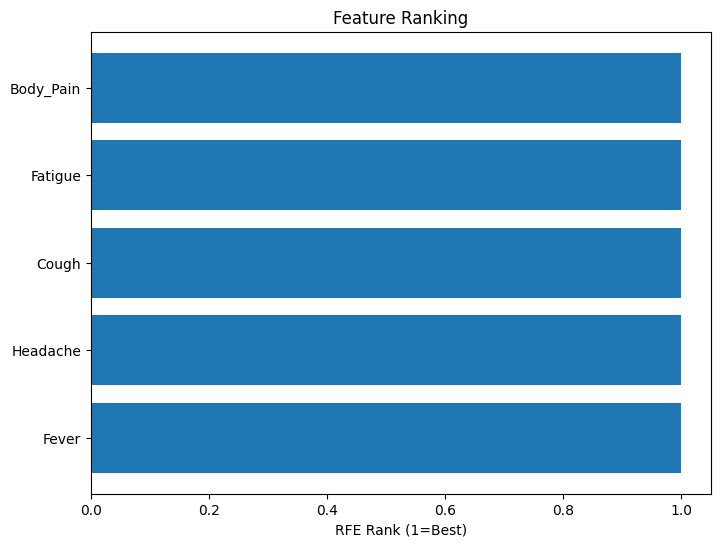

In [ ]:
# 7. Logistic Regression + RFE
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

logreg = LogisticRegression(max_iter=1000)
rfe = RFE(logreg, n_features_to_select=5)
rfe.fit(X_train, y_train)

selected_features = X_train.columns[rfe.support_]
print("Top 5 Selected Features:", selected_features)

# Ranking DataFrame
ranking = pd.DataFrame({'Feature': X_train.columns, 'Rank': rfe.ranking_})
ranking.sort_values('Rank', inplace=True)

# Plot feature ranking
plt.figure(figsize=(8,6))
plt.barh(ranking['Feature'], ranking['Rank'])
plt.xlabel("RFE Rank (1=Best)")
plt.title("Feature Ranking")
plt.show()


Performance with Selected Features:
Accuracy: 0.878
Precision: 0.8790406838029243
Recall: 0.878
F1 Score: 0.8779184288339977
ROC-AUC (ovr): 0.9858628571428572

Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.62      0.61       125
           1       1.00      1.00      1.00       125
           2       0.83      0.72      0.77       125
           3       0.73      0.77      0.75       125
           4       0.98      1.00      0.99       125
           5       1.00      0.98      0.99       125
           6       0.95      0.95      0.95       125
           7       0.94      0.98      0.96       125

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



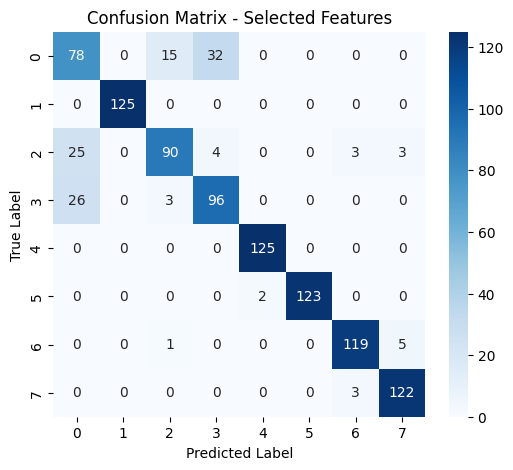


Performance with All Features:
Accuracy: 0.878
Precision: 0.8790406838029243
Recall: 0.878
F1 Score: 0.8779184288339977
ROC-AUC (ovr): 0.9858628571428572


In [ ]:
# 8. Model Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Train with selected features
logreg.fit(X_train[selected_features], y_train)
y_pred = logreg.predict(X_test[selected_features])
y_pred_proba = logreg.predict_proba(X_test[selected_features])

print("\nPerformance with Selected Features:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("ROC-AUC (ovr):", roc_auc_score(y_test, y_pred_proba, multi_class='ovr'))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Selected Features")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

# Train with all features
logreg.fit(X_train, y_train)
y_pred_all = logreg.predict(X_test)

print("\nPerformance with All Features:")
print("Accuracy:", accuracy_score(y_test, y_pred_all))
print("Precision:", precision_score(y_test, y_pred_all, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_all, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred_all, average='weighted'))
y_pred_proba_all = logreg.predict_proba(X_test)
print("ROC-AUC (ovr):", roc_auc_score(y_test, y_pred_proba_all, multi_class='ovr'))